<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/v3_Transformer_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer Module
Implements methodology requirements: DistilBERT fine-tuning, class weights, focal loss, calibration, explainability, uncertainty outputs, PR curves, and active learning scores.


In [1]:
!pip install transformers datasets evaluate captum scikit-learn torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 20.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import DistilBertTokenizer,DistilBertForSequenceClassification,Trainer,TrainingArguments
from sklearn.metrics import f1_score,classification_report,precision_recall_curve,average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt


In [36]:
import pandas as pd
import json

from google.colab import drive
drive.mount('/content/drive')
import os

project_folder = "/content/drive/MyDrive/Work Place Safety Insights"

train_df = pd.read_csv(f"{project_folder}/train.csv")
test_df = pd.read_csv(f"{project_folder}/test.csv")

# Convert severity_label to integer type
train_df["severity_label"] = train_df["severity_label"].astype(int)
test_df["severity_label"] = test_df["severity_label"].astype(int)

with open(f"{project_folder}/class_weights.json", "r") as f:
    class_weights = json.load(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
weights = [class_weights[str(i)] for i in sorted(map(int, class_weights.keys()))]
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

In [38]:
tokenizer=DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
def tokenize(texts):
 return tokenizer(list(texts), padding='max_length', truncation=True, max_length=256)

In [39]:
from torch.utils.data import Dataset
class SafetyDataset(Dataset):
 def __init__(self,texts,labels):
  self.enc=tokenize(texts)
  self.labels=list(labels)
 def __getitem__(self,idx):
  item={k:torch.tensor(v[idx]) for k,v in self.enc.items()}
  item['labels']=torch.tensor(self.labels[idx])
  return item
 def __len__(self):
  return len(self.labels)

In [40]:
print(train_df.columns)
print(test_df.columns)

Index(['Unnamed: 0', 'date', 'Countries', 'Local', 'Industry Sector',
       'accident_level', 'potential_accident_level', 'gender',
       'Employee or Third Party', 'critical_risk', 'description',
       'Unnamed: 11', 'Unnamed: 12', 'severity', 'potential_severity',
       'near_miss_gap', 'severity_label'],
      dtype='object')
Index(['Unnamed: 0', 'date', 'Countries', 'Local', 'Industry Sector',
       'accident_level', 'potential_accident_level', 'gender',
       'Employee or Third Party', 'critical_risk', 'description',
       'Unnamed: 11', 'Unnamed: 12', 'severity', 'potential_severity',
       'near_miss_gap', 'severity_label'],
      dtype='object')


In [41]:
train_dataset = SafetyDataset(
    train_df["description"],
    train_df["severity_label"]
)

test_dataset = SafetyDataset(
    test_df["description"],
    test_df["severity_label"]
)

In [42]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
# Focal Loss for Transformer models
# "If the model already predicts an example correctly with high confidence, don't spend much effort on it. Focus more on difficult or rare examples."

class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
    def forward(self,inputs,targets):
        ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
        pt=torch.exp(-ce)
        loss=((1-pt)**self.gamma)*ce
        return loss.mean()

alpha=class_weights_tensor # Use the pre-existing tensor
criterion=FocalLoss(alpha=class_weights_tensor,gamma=2.0) # Pass the tensor to FocalLoss
print('Focal loss ready for DistilBERT/BERT training.')

Focal loss ready for DistilBERT/BERT training.


In [47]:
from transformers import Trainer
class WeightedTrainer(Trainer):
 def compute_loss(self,model,inputs,return_outputs=False,**kwargs):
  labels=inputs.pop('labels')
  outputs=model(**inputs)
  logits=outputs.logits
  # Use the globally defined class_weights_tensor and move it to the device of logits
  loss=FocalLoss(alpha=class_weights_tensor.to(logits.device))(logits,labels)
  return (loss,outputs) if return_outputs else loss

***If the model already predicts an example correctly with high confidence, don't spend much effort on it. Focus more on difficult or rare examples.***

In [48]:
class FocalLoss(nn.Module):
 def __init__(self,alpha=None,gamma=2):
  super().__init__();self.alpha=alpha;self.gamma=gamma
 def forward(self,inputs,targets):
  ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
  pt=torch.exp(-ce)
  return (((1-pt)**self.gamma)*ce).mean()


In [49]:
args=TrainingArguments(output_dir='./results',num_train_epochs=5,per_device_train_batch_size=8,per_device_eval_batch_size=8,eval_strategy='epoch',save_strategy='no')
def compute_metrics(eval_pred):
 logits,labels=eval_pred
 preds=np.argmax(logits,axis=1)
 return {'macro_f1':f1_score(labels,preds,average='macro')}
trainer=WeightedTrainer(model=model,args=args,train_dataset=train_dataset,eval_dataset=test_dataset,compute_metrics=compute_metrics)


In [50]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [51]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [52]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.454448,0.650529
2,No log,0.445313,0.769958
3,No log,0.470263,0.797725
4,0.735544,0.488839,0.793829
5,0.735544,0.497576,0.808492


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=800, training_loss=0.4847512149810791, metrics={'train_runtime': 8638.2547, 'train_samples_per_second': 0.739, 'train_steps_per_second': 0.093, 'total_flos': 422924795788800.0, 'train_loss': 0.4847512149810791, 'epoch': 5.0})

In [53]:
import pandas as pd
import numpy as np

# Predict on the test dataset
predictions = trainer.predict(test_dataset)

# Raw logits
logits = predictions.predictions

# Predicted class
predicted_class = np.argmax(logits, axis=1)

# Softmax probabilities
probabilities = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

# Maximum confidence
confidence = probabilities.max(axis=1)

# Create dataframe
transformer_predictions = test_df.copy()

transformer_predictions["true_severity"] = test_df["severity_label"].values
transformer_predictions["predicted_severity"] = predicted_class
transformer_predictions["confidence"] = confidence

# Save probability of every class
for i in range(probabilities.shape[1]):
    transformer_predictions[f"prob_class_{i}"] = probabilities[:, i]

# Save CSV
transformer_predictions.to_csv(
    f"{project_folder}/transformer_predictions.csv",
    index=False
)

print(transformer_predictions.head())
print("Transformer predictions saved successfully!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   Unnamed: 0             date   Countries     Local Industry Sector  \
0       543.0         5/4/2017         NaN       NaN             NaN   
1       831.0  10/28/2016 0:00  Country_01  Local_02    Construction   
2      1232.0   9/29/2017 0:00  Country_01  Local_10   Manufacturing   
3        60.0    3/6/2016 0:00  Country_01  Local_04          Mining   
4       739.0        4/17/2017         NaN       NaN             NaN   

  accident_level potential_accident_level  gender Employee or Third Party  \
0              V                        V  Female                Employee   
1             IV                        V    Male                Employee   
2            III                       IV    Male                Employee   
3              I                      III    Male                Employee   
4              V                        V    Male                Employee   

          critical_risk  ... near_miss_gap  severity_label  true_severity  \
0            Laceration  ..

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print(classification_report(
    transformer_predictions["true_severity"],
    transformer_predictions["predicted_severity"]
))

cm = confusion_matrix(
    transformer_predictions["true_severity"],
    transformer_predictions["predicted_severity"]
)

print(cm)

              precision    recall  f1-score   support

           0       0.71      0.48      0.57        63
           1       0.75      0.83      0.79        60
           2       0.83      0.85      0.84        67
           3       0.79      0.92      0.85        66
           4       0.98      1.00      0.99        64

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.81       320
weighted avg       0.81      0.82      0.81       320

[[30 14  5 13  1]
 [ 5 50  3  2  0]
 [ 6  3 57  1  0]
 [ 1  0  4 61  0]
 [ 0  0  0  0 64]]


## Calibration
Apply temperature scaling or isotonic regression after training.


In [55]:
def temperature_scale(logits,T=1.5):
 return logits/T
# isotonic regression can be fit on validation probabilities.


## Validation Metrics


In [56]:
pred=trainer.predict(test_dataset)
preds=np.argmax(pred.predictions,axis=1)
print(classification_report(pred.label_ids,preds))
print('Macro F1=',f1_score(pred.label_ids,preds,average='macro'))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.71      0.48      0.57        63
           1       0.75      0.83      0.79        60
           2       0.83      0.85      0.84        67
           3       0.79      0.92      0.85        66
           4       0.98      1.00      0.99        64

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.81       320
weighted avg       0.81      0.82      0.81       320

Macro F1= 0.808492071102345


In [57]:
# Expected Calibration Error
def ece(probs,labels,n_bins=10):
 bins=np.linspace(0,1,n_bins+1)
 confidences=np.max(probs,axis=1)
 predictions=np.argmax(probs,axis=1)
 acc=(predictions==labels)
 score=0
 for i in range(n_bins):
  idx=(confidences>bins[i])&(confidences<=bins[i+1])
  if idx.sum()>0:
   score+=abs(acc[idx].mean()-confidences[idx].mean())*idx.mean()
 return score


In [ ]:
# Precision Recall curves for rare classes
# average_precision_score and precision_recall_curve can be computed per class.


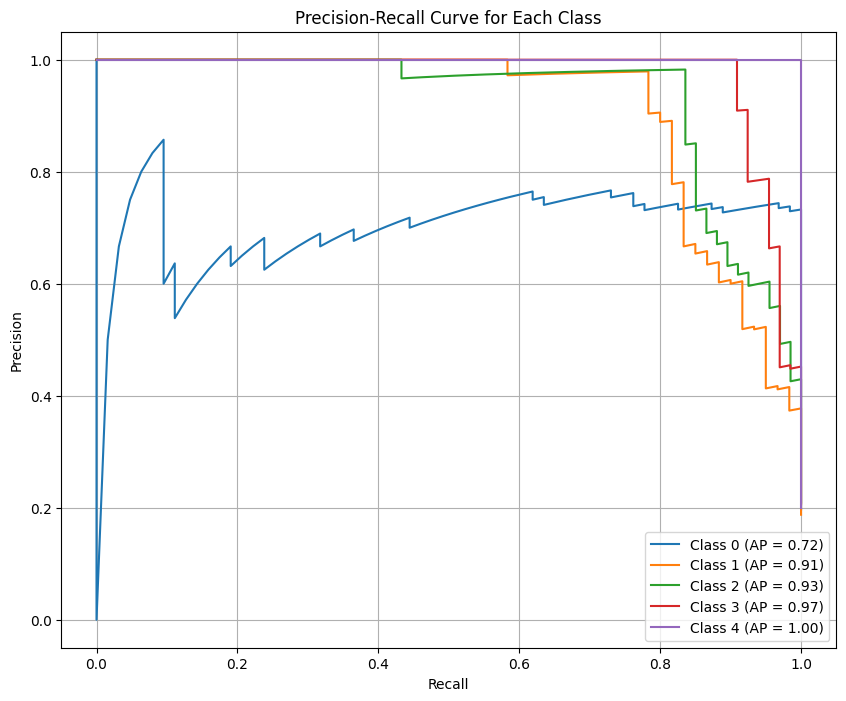

In [58]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import torch

# Get probabilities from the model's predictions
probs = torch.nn.functional.softmax(torch.tensor(pred.predictions), dim=-1).numpy()
labels = pred.label_ids

# Get the number of classes
n_classes = probs.shape[1]

# Plot PR curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(labels == i, probs[:, i])
    ap_score = average_precision_score(labels == i, probs[:, i])
    plt.plot(recall, precision, label=f'Class {i} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend()
plt.grid(True)
plt.show()

## Explainability


In [ ]:
# Integrated Gradients using Captum
# from captum.attr import IntegratedGradients
# Produces salient phrases responsible for predictions and can be linked to KG entities.


## Active Learning and Human-in-the-loop


In [ ]:
# Query uncertain samples
# uncertainty = 1-max(probabilities)
# Samples with high uncertainty or disagreement with Bayesian predictions
# should be sent for human annotation and KG updates.


## Outputs Required by Methodology
- Severity predictions
- Critical risk predictions (optional second head)
- Calibrated probabilities
- Macro and class-wise F1
- PR curves
- ECE score
- Integrated Gradients explanations
- Uncertainty scores for active learning
